# Scikit-learn PCA 實作

PCA 做的事像這樣：

先找一條「最重要的線」
這條線的方向是：
資料沿著它分散得最開（變異最大）
也就是「最能看出差異」的方向。
這條線叫 第一主成分（PC1）。

把每個點「打到這條線上」（投影）
你原本每個點有很多特徵（很多維），
投影後，你只要記得它在線上的位置（1 個數字）就好。
→ 多維變 1 維

如果你要保留更多資訊
再找第二條方向（PC2）：

它也要讓變異大

但不能跟第一條重複（要垂直/獨立）
然後投影到 PC1 + PC2 平面上
→ 多維變 2 維

In [1490]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1491]:
ds = datasets.load_wine()
df = pd.DataFrame(ds.data, columns=ds.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [1492]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = df.values
y = ds.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((124, 13), (54, 13), (124,), (54,))

In [1493]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [1494]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

## 特徵萃取(PCA)

In [1495]:
from sklearn.decomposition import PCA
pca1 = PCA(n_components=2)
X_train_pca = pca1.fit_transform(X_train_std)
X_test_pca = pca1.transform(X_test_std)
X_train_pca.shape,X_test_pca.shape

((124, 2), (54, 2))

## 5. 選擇演算法

In [1496]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [1497]:
clf.fit(X_train_std,y_train)

LogisticRegression()

In [1498]:
y_pred =  clf.predict(X_test_std)
print(f"{accuracy_score(y_test,y_pred):.2f}")

0.94


In [1499]:
from sklearn.linear_model import LogisticRegression
clf2 = LogisticRegression()

In [1500]:
clf2.fit(X_train_pca,y_train)

LogisticRegression()

In [1501]:
y_pred_pcac = clf2.predict(X_test_pca)
print(f"{accuracy_score(y_test,y_pred_pcac):.2f}")

0.94


# Scikit-learn LDA實作
它找一條（或幾條）線，讓不同類別的人在投影後分得最開、同一類的人聚得最緊。

In [1502]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1503]:
ds = datasets.load_wine()
df = pd.DataFrame(ds.data, columns=ds.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [1504]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 指定X、Y
X = df.values
y = ds.target

# 資料分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# 查看陣列維度
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [1505]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [1506]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)
X_train_lda.shape, X_test_lda.shape,y_train.shape,y_test.shape

((142, 2), (36, 2), (142,), (36,))

In [1507]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [1508]:
clf.fit(X_train_lda,y_train)

LogisticRegression()

In [1509]:
y_ored_lda = clf.predict(X_test_lda)
print(f"{accuracy_score(y_test,y_ored_lda):.2f}")

1.00


# 簡單線性回歸導論

簡單線性回歸的核心公式是找到最佳擬合直線，即所謂的回歸線，其公式可以表示為：

$ y = \beta_0 + \beta_1 x $

其中：
- $ y $ 是應變量（依賴變量）。
- $ x $ 是自變量（獨立變量）。
- $ \beta_0 $ 是截距，即直線在 $ y $ 軸的交點。
- $ \beta_1 $ 是斜率，表示 $ x $ 變動一單位時 $ y $ 的變動量。

### 參數估計
使用最小二乘法來估計 $ \beta_0 $ 和 $ \beta_1 $，計算公式如下：

$ \beta_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} $

$ \beta_0 = \bar{y} - \beta_1 \bar{x} $

其中：
- $ \bar{x} $ 和 $ \bar{y} $ 分別是 $ x $ 和 $ y $ 的平均值。
- $ n $ 是數據點的數量。

### 計算範例
假設我們有以下的數據點：

| $ x $ (年經驗) | $ y $ (年薪，單位：萬元) |
|---------|------------------|
| 1       | 3                |
| 2       | 4                |
| 3       | 5                |
| 4       | 6                |

我們要找到這些數據的線性回歸方程。首先計算 $ x $ 和 $ y $ 的平均值：

$[\bar{x} = \frac{1 + 2 + 3 + 4}{4} = 2.5]$

$ \bar{y} = \frac{3 + 4 + 5 + 6}{4} = 4.5 $

接下來計算斜率 $ \beta_1 $：

$ \beta_1 = \frac{(1-2.5)(3-4.5) + (2-2.5)(4-4.5) + (3-2.5)(5-4.5) + (4-2.5)(6-4.5)}{(1-2.5)^2 + (2-2.5)^2 + (3-2.5)^2 + (4-2.5)^2} = \frac{(-1.5)(-1.5) + (-0.5)(-0.5) + (0.5)(0.5) + (1.5)(1.5)}{2.5} = 1 $

計算截距 $ \beta_0 $：

$ \beta_0 = 4.5 - 1 \times 2.5 = 2 $

因此，回歸方程為：

$ y = 2 + 1x $

或簡化為：

$ y = 2 + x $

這樣，給定任何 $ x $ 的值，我們都可以使用這個方程來預測 $ y $ 的值。例如，若一人具有 5 年的經驗，其年薪預估為：

$ y = 2 + 5 = 7 $（單位：萬元）



In [1510]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1511]:
df = pd.read_csv("Advertising.csv")

In [1512]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [1513]:
df["total_spend"] = df["TV"] + df["radio"]+df["newspaper"]

<Axes: xlabel='total_spend', ylabel='sales'>

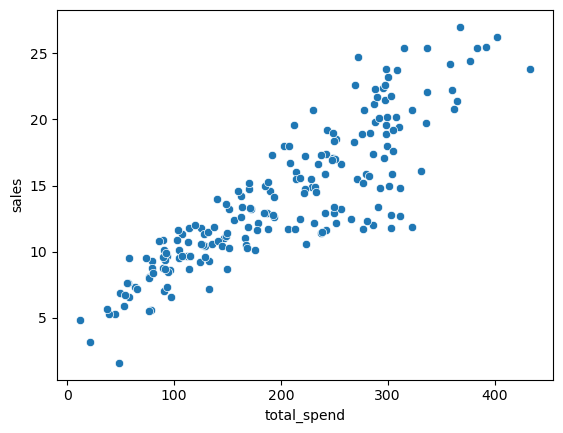

In [1514]:
sns.scatterplot(x="total_spend", y="sales", data=df)


$ y = \beta_0 + \beta_1 x $

其中：
- $ y $ 是應變量（依賴變量）。
- $ x $ 是自變量（獨立變量）。
- $ \beta_0 $ 是截距，即直線在 $ y $ 軸的交點。
- $ \beta_1 $ 是斜率，表示 $ x $ 變動一單位時 $ y $ 的變動量。

### 參數估計
使用最小二乘法來估計 $ \beta_0 $ 和 $ \beta_1 $，計算公式如下：

$ \beta_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} $

$ \beta_0 = \bar{y} - \beta_1 \bar{x} $

其中：
- $ \bar{x} $ 和 $ \bar{y} $ 分別是 $ x $ 和 $ y $ 的平均值。
- $ n $ 是數據點的數量。

In [1515]:
x = df["total_spend"]
y = df["sales"]

x_mean = np.mean(x)
y_mean = np.mean(y)
beta_1 = np.sum((x-x_mean)*(y-y_mean)) / np.sum((x-x_mean)**2)
beta_0 = y_mean - beta_1 * x_mean
# print(beta_1)
# print(beta_0)
print(f"回歸方程式:y={beta_0:.2f} + {beta_1:.2f}x")

回歸方程式:y=4.24 + 0.05x


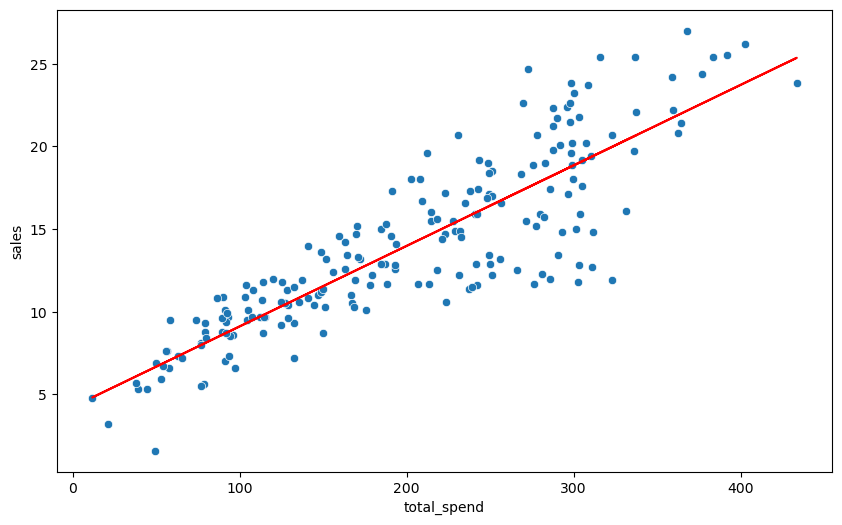

In [1516]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="total_spend",y="sales",data=df)
plt.plot(x,beta_0 + beta_1 * x,color = "red")

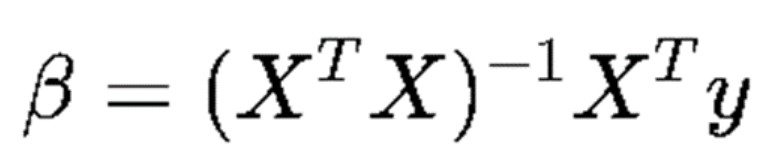

w[0,0] = β₁（斜率），

w[1,0] = β₀（截距）。

In [1517]:
import numpy as np

In [1518]:
year=[1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020]
pop=[2.53, 2.57, 2.62, 2.67, 2.71, 2.76, 2.81, 2.86, 2.92, 2.97, 3.03,
       3.08, 3.14, 3.2 , 3.26, 3.33, 3.4 , 3.47, 3.54, 3.62, 3.69, 3.77,
       3.84, 3.92, 4.  , 4.07, 4.15, 4.22, 4.3 , 4.37, 4.45, 4.53, 4.61,
       4.69, 4.78, 4.86, 4.95, 5.05, 5.14, 5.23, 5.32, 5.41, 5.49, 5.58,
       5.66, 5.74, 5.82, 5.9 , 5.98, 6.05, 6.13, 6.2 , 6.28, 6.36, 6.44,
       6.51, 6.59, 6.67, 6.75, 6.83, 6.92, 7.  , 7.08, 7.16, 7.24, 7.32,
       7.4 , 7.48, 7.56, 7.64, 7.72]

In [1519]:
X = np.array(year).reshape(-1,1)
y = np.array(pop).reshape(-1,1)
X.shape,y.shape

((71, 1), (71, 1))

In [1520]:
one = np.ones((X.shape[0],1))
print(one[0:5])
one.shape

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]]


(71, 1)

In [1521]:
X = np.concatenate((X,one),axis=1)
X.shape

(71, 2)

In [1522]:
w = np.linalg.inv(X.T @ X) @ X.T @ y
w

array([[ 7.72102616e-02],
       [-1.48313919e+02]])

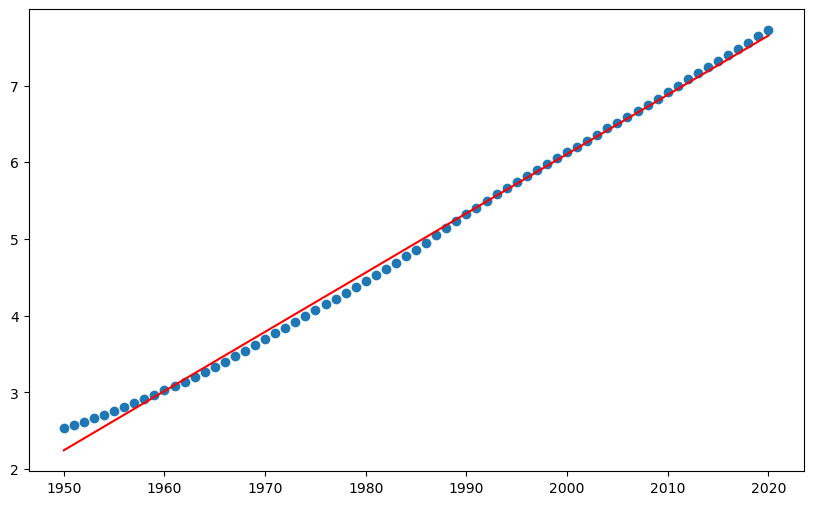

In [1523]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],y[:,0])
plt.plot(X[:,0],X[:,0]*w[0,0] + w[1,0],"r")

# 使用 SciKit-Learn 進行線性回歸


In [1524]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1525]:
df = pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 擴展問題

之前，我們探討了**總廣告支出與銷售之間是否存在關聯？**以及預測某一總支出值的總銷售量。現在我們想進一步探討**每個廣告渠道（電視、廣播、報紙）與銷售之間的關係是什麼？**

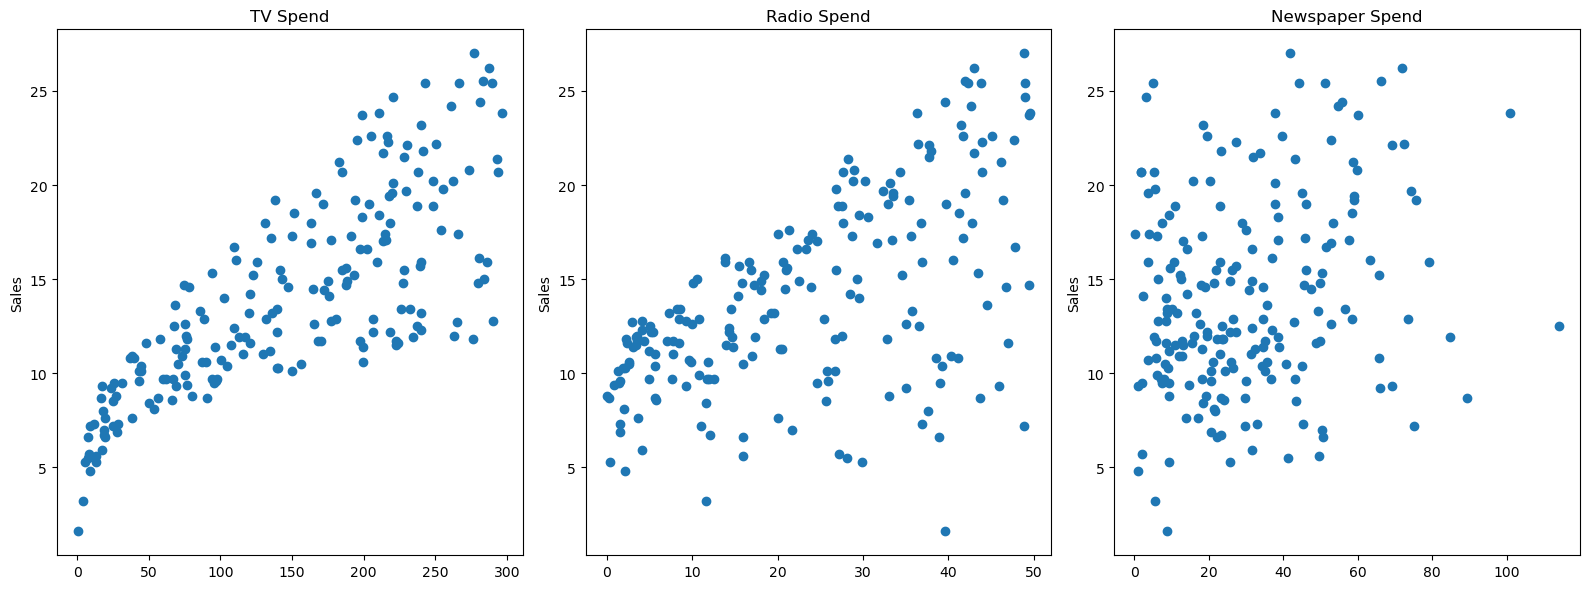

In [1526]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))

axes[0].plot(df['TV'],df['sales'],'o')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

axes[1].plot(df['radio'],df['sales'],'o')
axes[1].set_title("Radio Spend")
axes[1].set_ylabel("Sales")

axes[2].plot(df['newspaper'],df['sales'],'o')
axes[2].set_title("Newspaper Spend");
axes[2].set_ylabel("Sales")
plt.tight_layout()

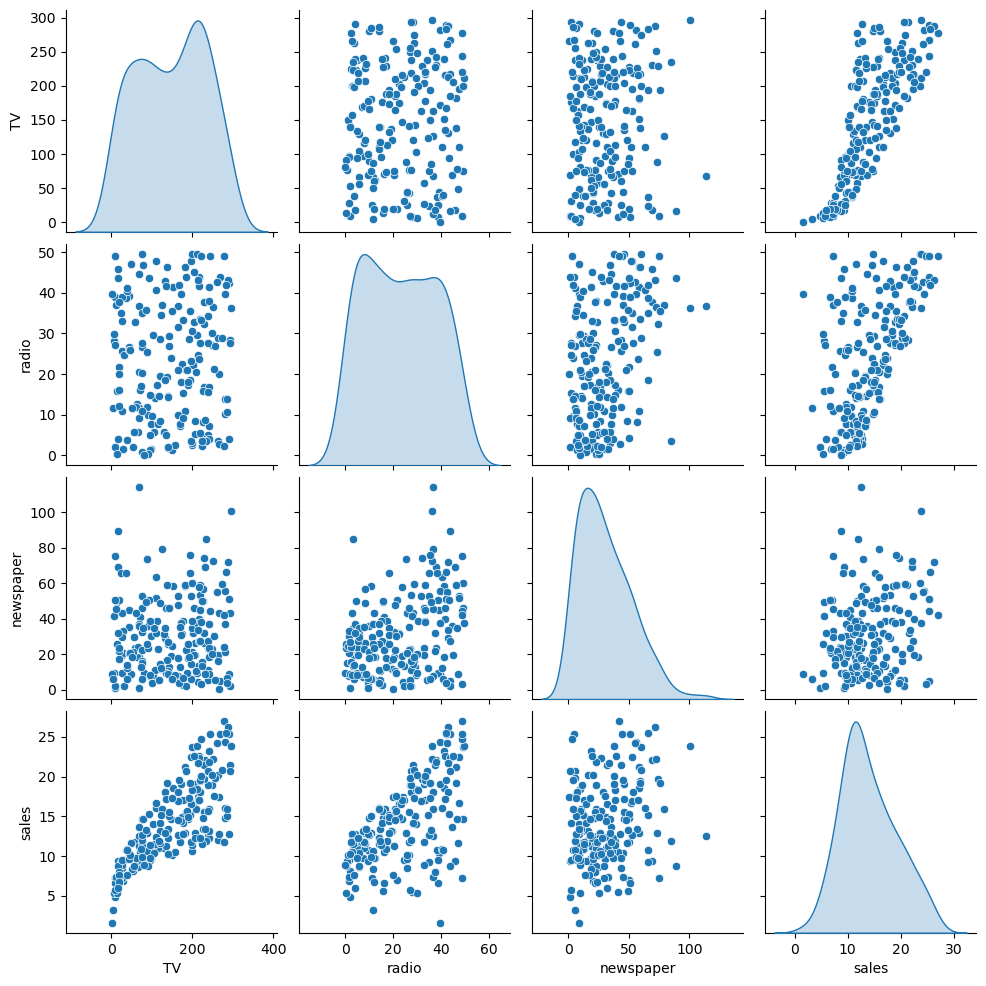

In [1527]:
sns.pairplot(df,diag_kind="kde")

In [1528]:
X = df.drop("sales",axis = 1)
y = df["sales"]

In [1529]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [1530]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()


In [1531]:
model.fit(X_train,y_train)

LinearRegression()

In [1532]:
test_pred = model.predict(X_test)

In [1533]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
MAE = mean_absolute_error(y_test,test_pred)
MSE = mean_squared_error(y_test,test_pred)
RMSE = np.sqrt(MSE)
print(f"MAE:{MAE:.2f}")
print(f"MSE:{MSE:.2f}")
print(f"RMSE:{RMSE:.2f}")

MAE:1.21
MSE:2.30
RMSE:1.52


In [1534]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [1535]:
with open("./housing.data",encoding="utf-8") as f:
    data = f.readlines()
all_fields = []
c =1
for line in data:
    line2 = line[1:].replace("   "," ").replace("  "," ")
    fields = []
    for item in line2.split(" "):
        fields.append(float(item.strip()))
        if len(fields) == 14:
            all_fields.append(fields)
df = pd.DataFrame(all_fields)
df.columns = 'CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV'.split(',')
df.head()            

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [1536]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [1537]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,1.716290,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,2.653510,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.250895,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,2.326717,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,9.966540,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [1538]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

<Axes: xlabel='MEDV', ylabel='Count'>

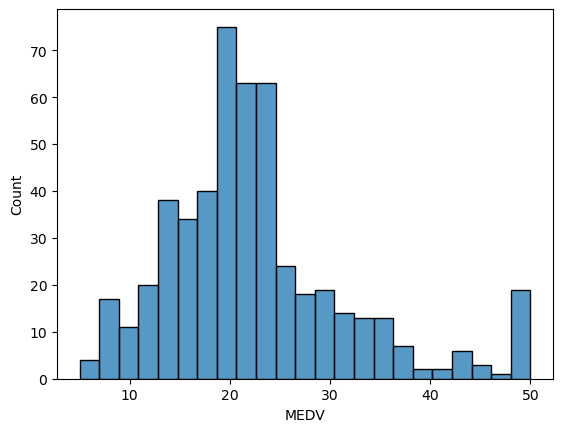

In [1539]:
import seaborn as sns
X,y = df.drop("MEDV",axis=1),df["MEDV"]
sns.histplot(x=y)

In [1540]:
# 資料分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# 查看陣列維度
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

In [1541]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [1542]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [1543]:
print(f"MSE={mean_squared_error(y_test,y_pred):.2f}")
print(f"MAE={mean_absolute_error(y_test,y_pred):.2f}")

MSE=20.32
MAE=3.29


In [1544]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [1545]:
df = pd.read_csv("Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [1546]:
X = df.drop("sales",axis=1)

In [1547]:
y = df["sales"]

In [1548]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [1549]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [1550]:
y_predict = model.predict(X_test)

In [1551]:
mean_squared_error(y_test,y_predict)

2.2987166978863782

### 從數據預處理中導入 PolynomialFeatures，這將幫助我們通過添加多項式特徵來轉換原始數據集

我們將從以下形式的方程開始（這裡假設我們只有一個 x 特徵）：

$$\hat{y} = \beta_0 + \beta_1x_1 + \epsilon $$

然後，為某個多項式的度數 \(d\)，從原始的 x 特徵創建更多的特徵。

$$\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_1^2 +  \ldots + \beta_dx_1^d + \epsilon$$

接著我們可以對這些新生成的多項式特徵進行線性回歸，因為實際上，我們只是將這些新的多項式特徵 $(x^2, x^3, \ldots, x^d) $ 當作新的特徵來處理。顯然，我們需要謹慎選擇正確的多項式度數 \(d\)（模型的度數），測試集上的指標結果將幫助我們確定這一點！

這種方法可以幫助我們擴展模型的表達能力，捕捉到數據中的非線性關係，從而提高模型的預測精度。

當使用 `PolynomialFeatures` 模塊時，如果將參數 `degree=2` 與 `include_bias=False` 設定，表示我們想生成二次多項式特徵，但不包括常數項（也就是截距項）。下面將用 LaTeX 格式詳細說明這一轉換過程：

### 原始特徵


$ \text{假設我們的原始特徵為}X=[x_1,x_2,x_3],$

### 二次多項式特徵

這會生成所有一次項、二次項及交互項的特徵。具體包括：

1.原始特徵的一次項：

$x_1,x_2,x_3$


2. 原始特徵的二次項：
$$x_1^2,x_2^2,x_3^2$$
### 3.原始特徵之間的交互項：
$$x_1x_2,x_1x_3,x_2x_3$$

因此，生成的二次多項式特徵可以表示為：

$X_{\mathrm{poly}}=[x_1,x_2,x_3,x_1^2,x_2^2,x_3^2,x_1x_2,x_1x_3,x_2x_3]$

### 具體公式

若用$\beta$表示回歸係數·用$\epsilon$表示誤差項·則二次多項式回歸模型可以表示為：
$$\hat{y}=\beta_0+\beta_1x_1+\beta_2x_2+\beta_3x_3+\beta_4x_1^2+\beta_5x_2^2+\beta_6x_3^2+\beta_7x_1x_2+\beta_8x_1x_3+\beta_9x_2x_3+\epsilon $$

由於設置了‘include\_bias=False’,這裡不包括常數項( $\beta_0$ )·因此實際的公式為：
$$\hat{y}=\beta_1x_1+\beta_2x_2+\beta_3x_3+\beta_4x_1^2+\beta_5x_2^2+\beta_6x_3^2+\beta_7x_1x_2+\beta_8x_1x_3+\beta_9x_2x_3+\epsilon $$



In [1552]:
from sklearn.preprocessing import PolynomialFeatures

In [1553]:
polynomial_conversion = PolynomialFeatures(degree=4,include_bias=False)
df = pd.read_csv("Advertising.csv")
df.head()
X = df.drop("sales",axis=1)
y = df["sales"]


In [1554]:
poly_features =  polynomial_conversion.fit_transform(X)
poly_features.shape

(200, 34)

In [1555]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [1556]:
from sklearn.linear_model import LinearRegression

In [1557]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train,y_train)

LinearRegression()

In [1558]:
test_pred = model.predict(X_test)

In [1559]:
MSE = mean_squared_error(y_test,test_pred)
MAE = mean_absolute_error(y_test,test_pred)
print(MSE,MAE)

0.25783470148579063 0.39260937376937266


---
---
### 選擇模型

#### 調整參數

我們對這個效能滿意嗎？也許更高的階數能進一步提升效能！但階數過高又會怎樣呢？現在我們可能需要回去調整我們的模型和參數，來探索更高階多項式的效果。這將很好地引入關於過度擬合的討論。

我們可以使用迴圈來完成以下事項：

1. 創建不同階數的多項式X數據
2. 將該多項式數據分割成訓練集和測試集
3. 在訓練數據上進行擬合
4. 回報訓練和測試結果的指標
5. 繪製這些結果並探討過度擬合

這段描述是要進行一個循環實驗，通過不斷提高多項式的階數，來觀察模型在訓練集和測試集上的表現，並透過繪圖來看過度擬合的情況。

In [1562]:
train_rmse_errors = []
test_rmse_errors = []
for d in range(1,10):
    polynomial_conversion = PolynomialFeatures(degree=d,include_bias=False)
    poly_features =  polynomial_conversion.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    model = LinearRegression(fit_intercept=True)
    model.fit(X_train,y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_RMSE = np.sqrt(mean_squared_error(y_train,train_pred))
    test_RMSE = np.sqrt(mean_squared_error(y_test,test_pred))

    train_rmse_errors.append(train_RMSE)
    test_rmse_errors.append(test_RMSE)

train_rmse_errors


[1.734594124329376,
 0.5879574085292232,
 0.4339344356902066,
 0.35170836883993517,
 0.2509342951990972,
 0.19940660520798886,
 5.421526785539996,
 0.14202305096575807,
 0.16722016522462252]

In [1563]:
test_rmse_errors

[1.5161519375993877,
 0.6646431757269152,
 0.5803286825156331,
 0.5077742623309994,
 2.5758247707699113,
 4.490840128985557,
 1381.247040053768,
 4450.02249855719,
 95899.77715376193]

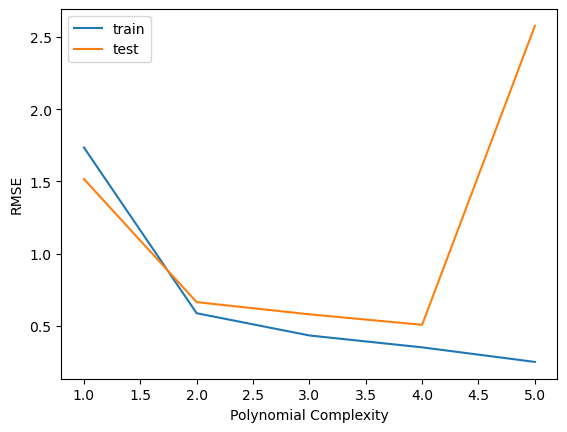

In [1564]:
plt.plot(range(1,6),train_rmse_errors[:5],label="train")
plt.plot(range(1,6),test_rmse_errors[:5],label="test")
plt.xlabel("Polynomial Complexity")
plt.ylabel("RMSE")
plt.legend()
plt.show()

## Ridge Regression

Ridge 回歸（Ridge Regression），又稱為 Tikhonov 正則化，是一種用於多重共線性數據分析的線性回歸方法。它透過在最小二乘函數（即，誤差平方和）中添加一個稱為 L2 正則化項的懲罰因子來修改傳統的線性回歸模型。這個懲罰因子涉及所有模型參數的平方和。

### Ridge 回歸的數學表達式：
Ridge 回歸的目標函數可以寫成：
$ [ \text{RSS} + \lambda \sum_{j=1}^p \beta_j^2 ]$
其中，RSS 是殘差平方和，$(\beta_j)$ 是模型參數，$(p)$ 是參數的數量，而 $(\lambda)$ 是一個非負的調節參數（稱為正則化參數），用來控制懲罰的強度。

### Ridge 回歸的特點和用途：
1. **縮小係數**：Ridge 回歸通過縮小不重要特徵的影響（即係數接近於零）來減少模型的複雜性和過擬合的風險。
2. **處理共線性**：當數據集中存在高度相關的解釋變量時，傳統的線性回歸可能會失效，而 Ridge 回歸可以有效地解決這一問題。
3. **參數選擇**：正則化參數 $(\lambda)$ 的選擇對模型性能有顯著影響。一般通過交叉驗證來選擇最佳的 $(\lambda)$ 值。

總之，Ridge 回歸是一種強大的線性模型，適用於包含大量特徵的數據集，特別是當這些特徵相互之間存在較強相關性時。通过正確的正則化參數設置，Ridge 回歸有助於提高模型的泛化能力。

In [1576]:
from sklearn.linear_model import Ridge

In [1577]:
ridge_model = Ridge(alpha=10)

In [1578]:
df = pd.read_csv("Advertising.csv")
X = df.drop('sales',axis=1)
y = df['sales']

In [1579]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_converter = PolynomialFeatures(degree=3,include_bias=False)
poly_features = polynomial_converter.fit_transform(X)

In [1580]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [1581]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [1582]:
ridge_model.fit(X_train,y_train)

Ridge(alpha=10)

In [1583]:
test_predictions =ridge_model.predict(X_test)

In [1584]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
print(MAE,MSE)

0.5774404204714176 0.800378307152841



-----

## Lasso Regression


Lasso 回歸（Least Absolute Shrinkage and Selection Operator Regression，簡稱 Lasso）是一種線性回歸的改進方法，它在傳統的最小二乘法基礎上加入了 L1 正則化項。這種正則化不僅可以防止過擬合，還能進行變量選擇，即自動選擇並保留最重要的特徵，而將其他不重要的特徵的係數縮減至零。

### Lasso 回歸的數學表達式：
Lasso 回歸的目標函數可以寫成：
$[ \text{RSS} + \lambda \sum_{j=1}^p |\beta_j| ]$
其中，RSS 是殘差平方和，$(\beta_j)$ 是模型參數，$(p)$ 是參數的數量，而 $(\lambda)$ 是正則化參數，控制著懲罰的強度。

### Lasso 回歸的特點和用途：
1. **特徵選擇**：Lasso 回歸可以自動進行特徵選擇，將不重要的特徵係數縮減為零，這是由於 L1 正則化促使係數成為稀疏的。
2. **預防過擬合**：通過限制模型參數的總量，Lasso 回歸有助於降低模型在訓練數據上的過擬合風險。
3. **處理共線性**：和 Ridge 回歸一樣，Lasso 也能處理變量之間的高度相關性問題。

Lasso 回歸特別適用於那些特徵數量遠多於樣本數的情況（即高維數據集），它能有效地減少模型中的變量數量，從而簡化模型，增強模型的可解釋性，同時保持模型的預測性能。在實際應用中，選擇最佳的 $(\lambda)$ 值通常需要通過交叉驗證來進行。

In [1585]:
from sklearn.linear_model import LassoCV
lasso_cv_model = LassoCV(eps=0.1,n_alphas=100,cv=5)
lasso_cv_model.fit(X_train,y_train)


LassoCV(cv=5, eps=0.1)

In [1586]:
test_pred =  lasso_cv_model.predict(X_test)

MAE = mean_absolute_error(y_test,test_pred)
MSE = mean_squared_error(y_test,test_pred)
print(MAE,MSE)

0.6541723161252854 1.2787088713079842


## Elastic Net

Elastic Net 回歸是一種結合了 Ridge 回歸和 Lasso 回歸的線性回歸模型，它在模型中同時引入了 L1 正則化和 L2 正則化。這種組合使得 Elastic Net 能夠結合兩種回歸的優點，特別是在處理具有多重共線性特徵或特徵數量遠多於樣本數的數據集時表現出色。

### Elastic Net 回歸的數學表達式：
Elastic Net 的目標函數可以寫成：
$[ \text{RSS} + \lambda_1 \sum_{j=1}^p |\beta_j| + \lambda_2 \sum_{j=1}^p \beta_j^2 ]$
其中，RSS 是殘差平方和，$(\beta_j)$ 是模型參數，$(p)$ 是參數的數量，$(\lambda_1)$ 和 $(\lambda_2)$ 分別是控制 L1 正則化和 L2 正則化的參數。

### Elastic Net 回歸的特點和用途：
1. **特徵選擇與縮減**：Elastic Net 可以像 Lasso 一樣進行特徵選擇，也可以像 Ridge 一樣縮減特徵係數，結合了兩者的特性。
2. **處理共線性與數據疏散問題**：當數據集中的變量高度相關或數據點較少時，Elastic Net 通過 L1 和 L2 正則化提供更穩定的解。
3. **靈活的調節**：通過調節 $(\lambda_1)$ 和 $(\lambda_2)$ 的值，可以在純 Lasso 和純 Ridge 回歸之間進行平衡，這使得 Elastic Net 非常靈活，適應不同的數據情況。

Elastic Net 回歸尤其適用於那些變量之間存在強共線性，或者特徵數量遠大於樣本數的情況，這種情況下單獨使用 Lasso 或 Ridge 可能不夠有效。同樣，確定最佳的 $(\lambda_1)$ 和 $(\lambda_2)$ 值通常需要通過交叉驗證來實現。

In [1587]:
from sklearn.linear_model import ElasticNetCV

In [1588]:
#tol「收斂容忍度」（tolerance）
ellipsis_mode = ElasticNetCV(l1_ratio=[.1,.5,.7,.9,.95,1],tol=0.01)

In [1589]:
ellipsis_mode.fit(X_train,y_train)


ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1], tol=0.01)

In [1590]:
ellipsis_mode.l1_ratio_

1.0

In [1591]:
test_pred = ellipsis_mode.predict(X_test)
MAE = mean_absolute_error(y_test,test_pred)
MSE = mean_squared_error(y_test,test_pred)
print(MAE,MSE)

0.5663262117569448 0.5603340214638836


## L1實驗

In [1592]:
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

In [1615]:
# 生成示例數據，添加一些不相關的特徵和增加噪音
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=10, noise=10, random_state=42)
# 添加20個不相關的特徵
X = np.hstack([X, np.random.randn(100, 20)])

# 分割數據為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 不使用L1正則化的線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Linear Regression Mean Squared Error: {mse}')

# 使用L1正則化的Lasso模型
lasso = Lasso(alpha=0.3)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f'Lasso Regression Mean Squared Error: {mse_lasso}')


Linear Regression Mean Squared Error: 176.42544323621857
Lasso Regression Mean Squared Error: 159.06667378029192
